# Exploratory Data Analysis — Fitness Activity Prediction
**Цель:** Понять данные, найти аномалии, сформулировать гипотезы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/dailyActivity_merged.csv')

df.columns = [
    'user_id', 'date', 'steps', 'total_distance', 'tracker_distance',
    'logged_distance', 'very_active_dist', 'moderate_active_dist',
    'light_active_dist', 'sedentary_dist', 'very_active_min',
    'fairly_active_min', 'lightly_active_min', 'sedentary_min', 'calories'
]

df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['active_minutes'] = df['very_active_min'] + df['fairly_active_min'] + df['lightly_active_min']

print(f'Размер датасета: {df.shape}')
print(f'Кол-во пользователей: {df["user_id"].nunique()}')
print(f'Временной диапазон: {df["date"].min()} — {df["date"].max()}')

Размер датасета: (940, 17)
Кол-во пользователей: 33
Временной диапазон: 2016-04-12 00:00:00 — 2016-05-12 00:00:00


## 2. Базовая статистика

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               940 non-null    int64         
 1   date                  940 non-null    datetime64[ns]
 2   steps                 940 non-null    int64         
 3   total_distance        940 non-null    float64       
 4   tracker_distance      940 non-null    float64       
 5   logged_distance       940 non-null    float64       
 6   very_active_dist      940 non-null    float64       
 7   moderate_active_dist  940 non-null    float64       
 8   light_active_dist     940 non-null    float64       
 9   sedentary_dist        940 non-null    float64       
 10  very_active_min       940 non-null    int64         
 11  fairly_active_min     940 non-null    int64         
 12  lightly_active_min    940 non-null    int64         
 13  sedentary_min       

In [4]:
df[['steps', 'calories', 'active_minutes', 'sedentary_min']].describe().round(2)

,steps,calories,active_minutes,sedentary_min
count,940.00,940.00,940.00,940.00
mean,7637.91,2303.61,227.54,991.21
std,5087.15,718.17,121.78,301.27
min,0.00,0.00,0.00,0.00
25%,3789.75,1828.50,146.75,729.75
50%,7405.50,2134.00,247.00,1057.50
75%,10727.00,2793.25,317.25,1229.50
max,36019.00,4900.00,552.00,1440.00


## 3. Пропуски и дубликаты

In [5]:
print('=== Пропуски ===')
print(df.isnull().sum())

print(f'\n=== Дубликаты ===')
print(f'Полных дубликатов: {df.duplicated().sum()}')
print(f'Дубликатов (user_id + date): {df.duplicated(["user_id", "date"]).sum()}')

=== Пропуски ===
user_id                 0
date                    0
steps                   0
total_distance          0
tracker_distance        0
logged_distance         0
very_active_dist        0
moderate_active_dist    0
light_active_dist       0
sedentary_dist          0
very_active_min         0
fairly_active_min       0
lightly_active_min      0
sedentary_min           0
calories                0
day_of_week             0
active_minutes          0
dtype: int64

=== Дубликаты ===
Полных дубликатов: 0
Дубликатов (user_id + date): 0


## 4. Графики
### 4.1 Распределение шагов (обычная + log scale)

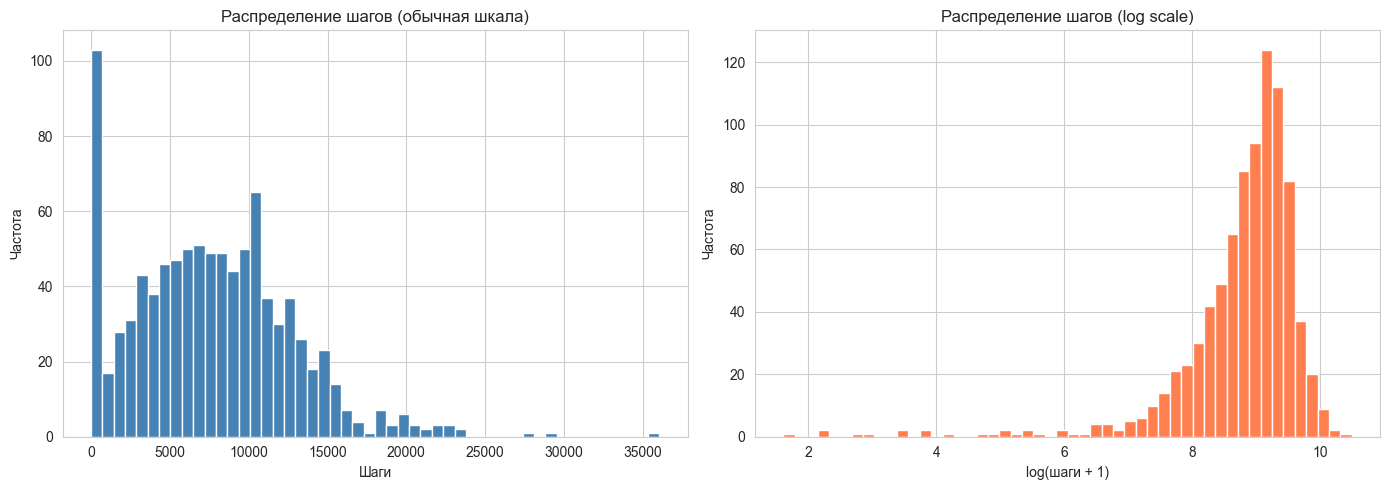

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['steps'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение шагов (обычная шкала)')
axes[0].set_xlabel('Шаги')
axes[0].set_ylabel('Частота')

steps_nonzero = df[df['steps'] > 0]['steps']
axes[1].hist(np.log1p(steps_nonzero), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Распределение шагов (log scale)')
axes[1].set_xlabel('log(шаги + 1)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('../report/steps_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.2 Средние шаги по дням недели

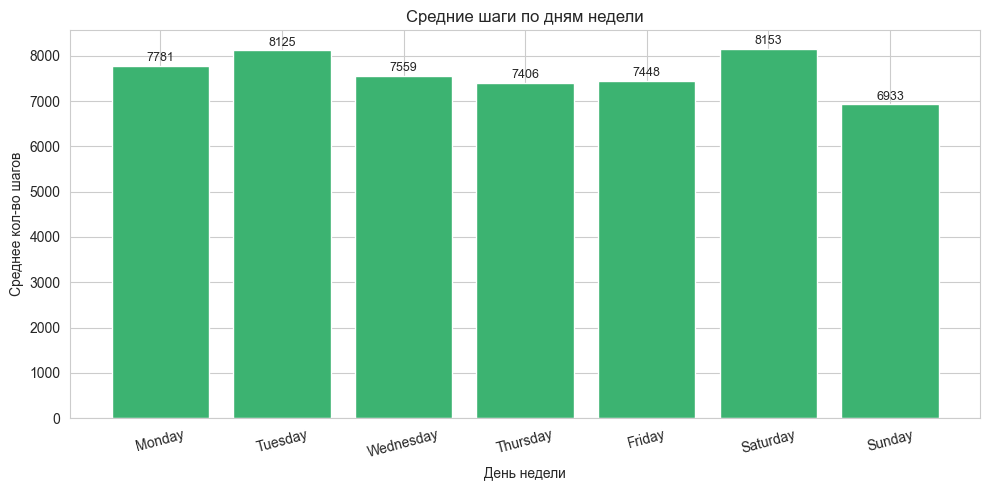

In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = df.groupby('day_of_week')['steps'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_by_day.index, avg_by_day.values, color='mediumseagreen', edgecolor='white')
plt.title('Средние шаги по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее кол-во шагов')
plt.xticks(rotation=15)
for bar, val in zip(bars, avg_by_day.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../report/steps_by_weekday.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.3 Временной ряд для 5 пользователей

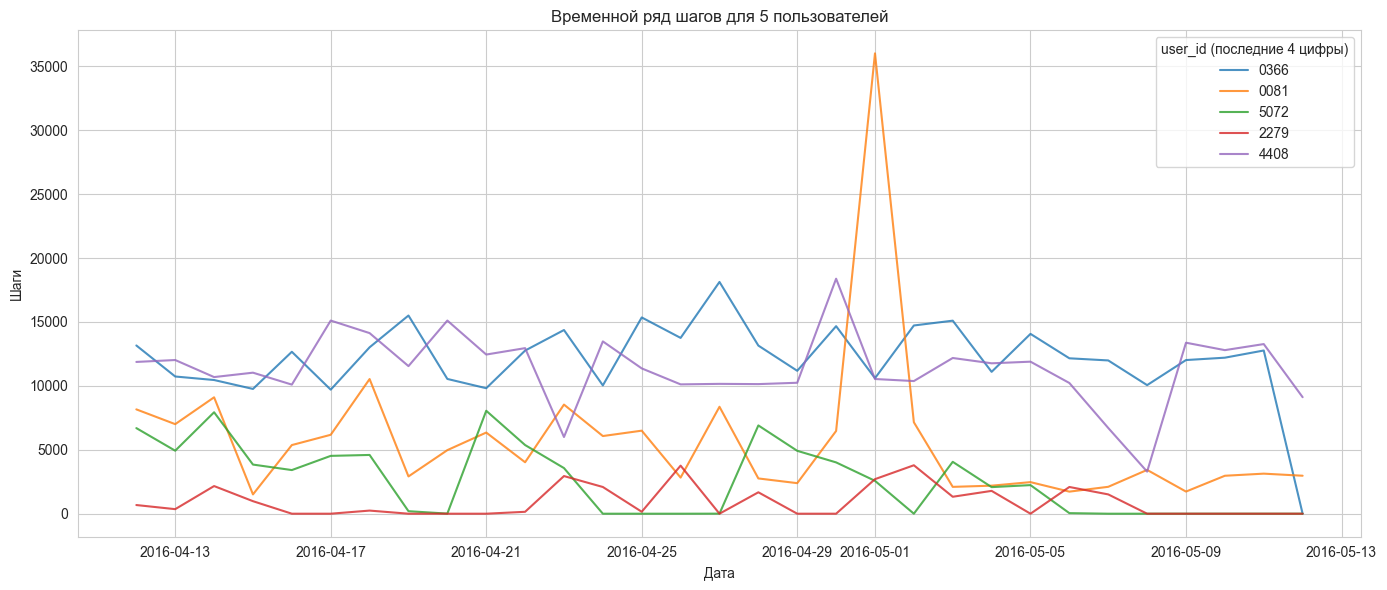

In [8]:
top_users = df.groupby('user_id')['steps'].count().nlargest(5).index

plt.figure(figsize=(14, 6))
for uid in top_users:
    user_data = df[df['user_id'] == uid].sort_values('date')
    plt.plot(user_data['date'], user_data['steps'], label=str(uid)[-4:], alpha=0.8)

plt.title('Временной ряд шагов для 5 пользователей')
plt.xlabel('Дата')
plt.ylabel('Шаги')
plt.legend(title='user_id (последние 4 цифры)')
plt.tight_layout()
plt.savefig('../report/steps_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.4 Корреляционная тепловая карта

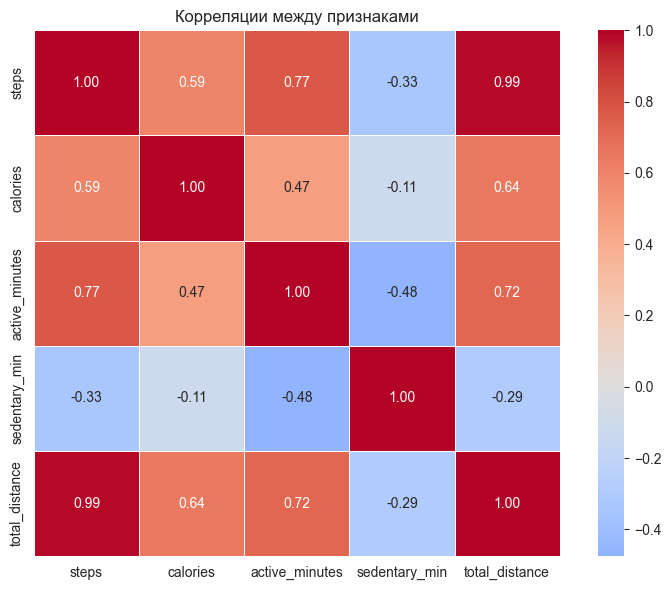

In [9]:
cols = ['steps', 'calories', 'active_minutes', 'sedentary_min', 'total_distance']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляции между признаками')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.5 Шаги vs Калории

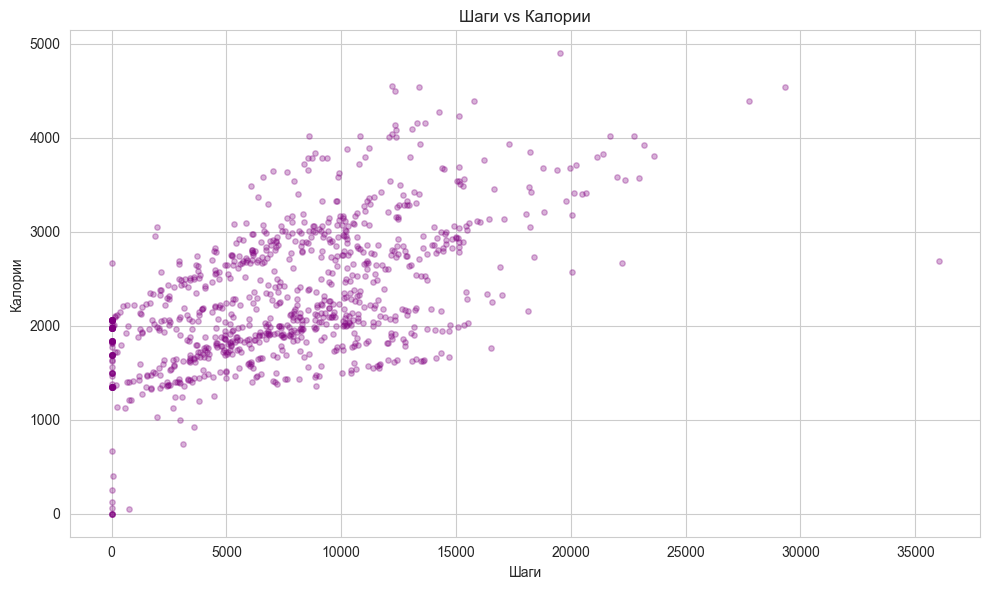

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['steps'], df['calories'], alpha=0.3, color='purple', s=15)
plt.title('Шаги vs Калории')
plt.xlabel('Шаги')
plt.ylabel('Калории')
plt.tight_layout()
plt.savefig('../report/steps_vs_calories.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Аномалии

In [11]:
zero_steps = df[df['steps'] == 0]
outliers = df[df['steps'] > 50000]

print(f'Записей с 0 шагов: {len(zero_steps)} ({len(zero_steps)/len(df)*100:.1f}%)')
print(f'Записей с >50000 шагов: {len(outliers)}')

if len(outliers) > 0:
    print('\nВыбросы (>50000 шагов):')
    print(outliers[['user_id', 'date', 'steps']].to_string())

print(f'\nМин. шагов: {df["steps"].min()}')
print(f'Макс. шагов: {df["steps"].max()}')
print(f'Медиана шагов: {df["steps"].median():.0f}')

Записей с 0 шагов: 77 (8.2%)
Записей с >50000 шагов: 0

Мин. шагов: 0
Макс. шагов: 36019
Медиана шагов: 7406


## 6. Ключевые наблюдения

1. **Распределение шагов правостороннее** — большинство пользователей делают 5000–10000 шагов в день, но есть длинный хвост с высокими значениями. В log-шкале распределение ближе к нормальному.

2. **Активность по дням недели неравномерна** — пользователи более активны в будние дни (особенно вторник–среда), в выходные активность немного снижается.

3. **Высокая корреляция шагов с калориями и дистанцией** — шаги сильно коррелируют с `total_distance` (>0.9) и `calories` (~0.6). `sedentary_min` имеет отрицательную корреляцию с шагами.

4. **Дни с 0 шагов — потенциальные аномалии** — значительная доля записей имеет 0 шагов, что может означать, что пользователь не носил трекер, а не реальную нулевую активность. Такие дни нужно обрабатывать отдельно.

5. **Поведение пользователей сильно различается** — временные ряды показывают, что у разных пользователей разные паттерны активности: одни стабильны, другие имеют резкие спады и подъёмы. Это важно учитывать при построении user-specific модели.